<a href="https://colab.research.google.com/github/ingcamilofola-jpg/connectatel-analysis/blob/main/connectatel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

# Ver primeras filas
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [3]:
# Ver primeras filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [4]:
# Ver primeras filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [7]:
# Número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [8]:
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## 1.2 Exploración de la estructura

- plans: 2 filas, 8 columnas, sin nulos
- users: 4000 filas, 8 columnas. city tiene 469 nulos. reg_date está como object (hay que convertir a fecha)
- usage: 40000 filas, 6 columnas. date tiene 50 nulos

## 2.1 Revisión de valores nulos

In [11]:
# Nulos en users
print("=== USERS ===")
print("Cantidad de nulos:")
print(users.isnull().sum())
print("\nProporción de nulos:")
print(users.isnull().sum() / len(users))

=== USERS ===
Cantidad de nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# Nulos en usage
print("=== USAGE ===")
print("Cantidad de nulos:")
print(usage.isnull().sum())
print("\nProporción de nulos:")
print(usage.isnull().sum() / len(usage))

=== USAGE ===
Cantidad de nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


### Diagnóstico de nulos

**USERS:**
- city: 469 nulos (11.7%) → Reemplazar con pd.NA (ya hay un sentinel "?" también)
- churn_date: 3534 nulos (88.3%) → Son usuarios activos, se deja como está ✅

**USAGE:**
- date: 50 nulos (0.1%) → Muy pocos, se marcarán como pd.NA
- duration: 22076 nulos (55%) → Normal, son los registros de mensajes (type=text)
- length: 17896 nulos (44.7%) → Normal, son los registros de llamadas (type=call)

In [13]:
# Explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [14]:
# Explorar columnas categóricas de users
print(users['city'].value_counts())
print("\n")
print(users['plan'].value_counts())

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64


plan
Basico     2595
Premium    1405
Name: count, dtype: int64


In [15]:
# Explorar columna type de usage
print(usage['type'].value_counts())

type
text    22092
call    17908
Name: count, dtype: int64


### Diagnóstico de valores inválidos (sentinels)

**USERS:**
- age: tiene valor mínimo -999 → es un sentinel, reemplazar con la mediana (47)
- city: tiene 96 registros con "?" → es un sentinel, reemplazar con pd.NA
- plan: solo tiene "Basico" y "Premium" → correcto ✅

**USAGE:**
- type: solo tiene "text" y "call" → correcto ✅

In [16]:
# Convertir fechas con errors='coerce' (fechas inválidas se vuelven NaT)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Revisar años en reg_date de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date:
reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


In [17]:
# Revisar años en date de usage
print("Años en date de usage:")
print(usage['date'].dt.year.value_counts().sort_index())

Años en date de usage:
date
2024.0    39950
Name: count, dtype: int64


### Diagnóstico de fechas

**reg_date (users):**
- 2022: 1314, 2023: 1316, 2024: 1330 → fechas válidas ✅
- 2026: 40 registros → fechas FUTURAS, imposibles (datos hasta 2024) ⚠️
  → Se marcarán como pd.NA

**date (usage):**
- 2024: 39950 registros → todo correcto ✅
- 50 nulos → ya detectados antes

In [18]:
# 1. Reemplazar sentinel -999 en age con la mediana
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar
print("Mediana usada:", age_mediana)
users['age'].describe()

Mediana usada: 48.0


,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [19]:
# 2. Reemplazar "?" por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar
print(users['city'].value_counts())

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64


In [20]:
# 3. Marcar fechas futuras (2026) como NA en reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar
print(users['reg_date'].dt.year.value_counts().sort_index())

reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64


In [21]:
# Verificar MAR: nulos en duration dependen de type?
print("Nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isnull().sum()))

Nulos en duration por type:
type
call        0
text    22076
Name: duration, dtype: int64


In [22]:
# Verificar MAR: nulos en length dependen de type?
print("Nulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isnull().sum()))

Nulos en length por type:
type
call    17896
text        0
Name: length, dtype: int64


### Diagnóstico MAR en usage

- duration: todos los nulos (22076) están en type=text → correcto ✅
  Los mensajes no tienen duración, se dejan como NaN
  
- length: todos los nulos (17896) están en type=call → correcto ✅
  Las llamadas no tienen longitud de texto, se dejan como NaN

Conclusión: son Missing At Random (MAR), dependen del tipo de registro.
No se imputan, se mantienen como NaN.

In [23]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [24]:
# Combinar con users
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [25]:
# Paso 4.2 - Resumen estadístico de columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [26]:
# Distribución porcentual del plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64


### Resumen estadístico - Paso 4.2

**Edad (age):**
- Rango: 18 a 79 años, mediana 48 años

**Mensajes (cant_mensajes):**
- Promedio: 5.5, mediana: 5, máximo: 17

**Llamadas (cant_llamadas):**
- Promedio: 4.5, mediana: 4, máximo: 15

**Minutos de llamada (cant_minutos_llamada):**
- Promedio: 23.3 min, mediana: 19.8, máximo: 155.69 → posibles outliers ⚠️

**Distribución de planes:**
- Básico: 64.9% de los usuarios
- Premium: 35.1% de los usuarios

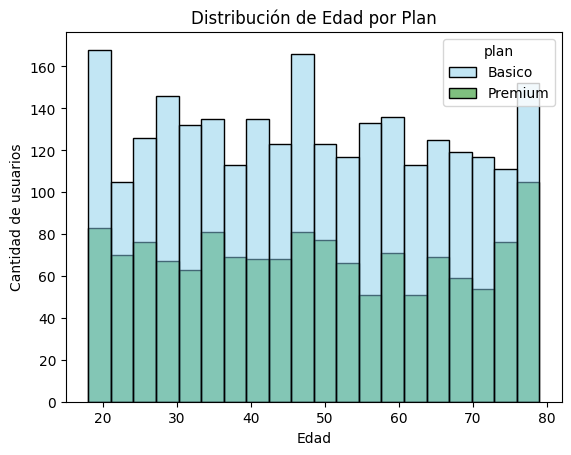

In [27]:
# Histograma de edad
sns.histplot(data=user_profile, x='age', hue='plan',
             palette=['skyblue','green'], bins=20)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

### Insight - Distribución de Edad
- Distribución relativamente simétrica entre 18 y 79 años
- El plan Básico domina en todos los grupos de edad
- El plan Premium tiene mayor proporción en usuarios de 30-50 años

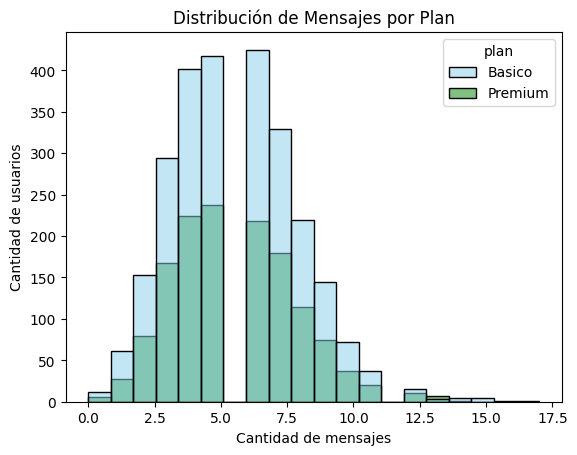

In [28]:
# Histograma de mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue','green'], bins=20)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

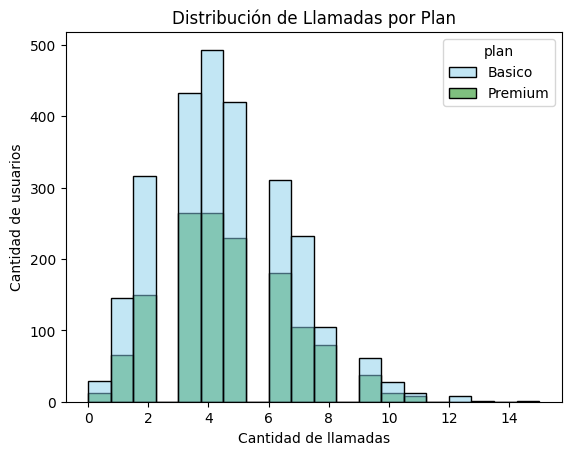

In [29]:
# Histograma de llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue','green'], bins=20)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

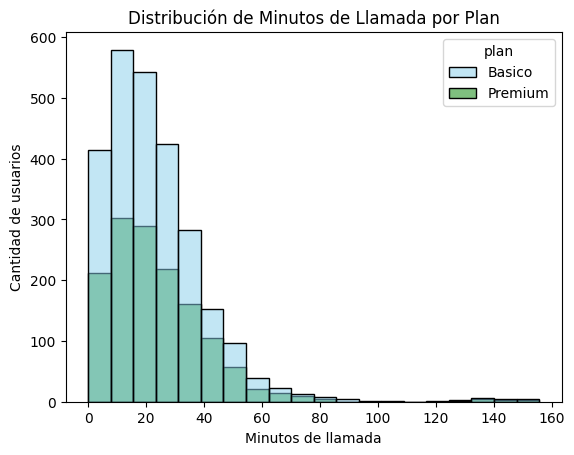

In [30]:
# Histograma de minutos
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue','green'], bins=20)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

### Insights - Histogramas

**Mensajes (cant_mensajes):**
- Distribución sesgada a la derecha
- La mayoría de usuarios envía entre 3 y 7 mensajes
- No hay diferencia notable entre plan Básico y Premium

**Llamadas (cant_llamadas):**
- Distribución sesgada a la derecha
- La mayoría realiza entre 2 y 6 llamadas
- Ambos planes se comportan de forma similar

**Minutos de llamada (cant_minutos_llamada):**
- Distribución muy sesgada a la derecha
- La mayoría usa entre 0 y 40 minutos
- Hay algunos usuarios con más de 100 minutos → posibles outliers ⚠️
- No hay diferencia clara entre planes

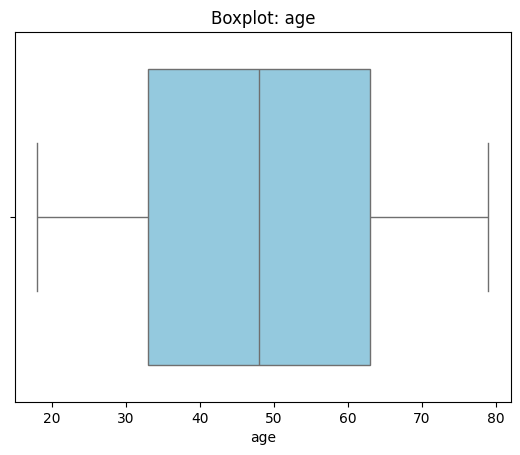

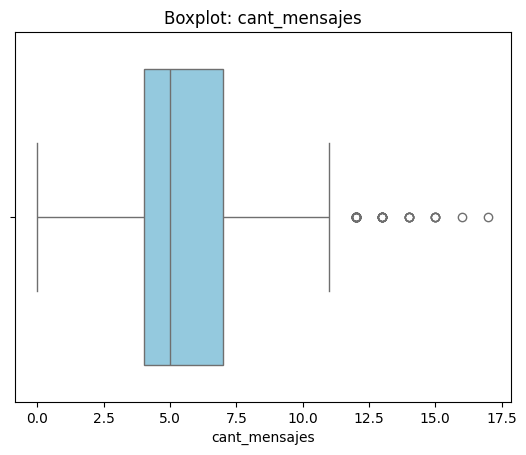

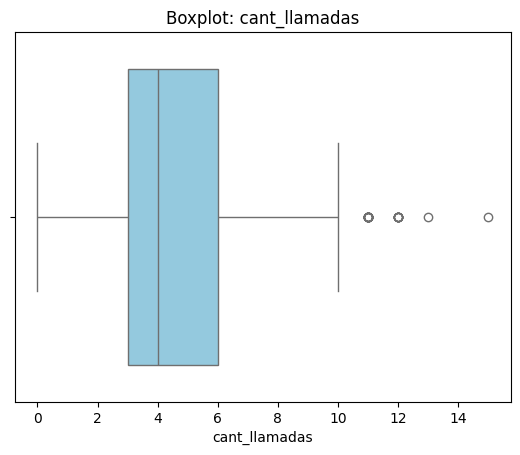

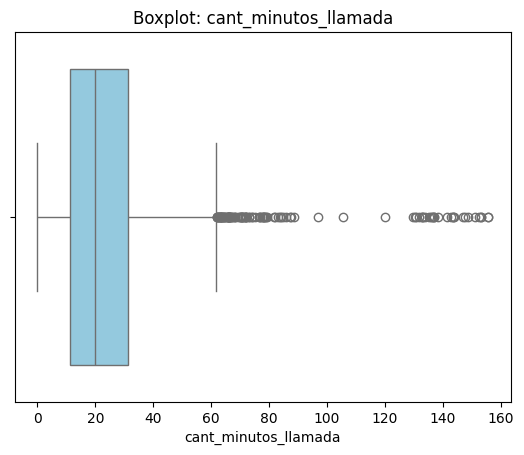

In [31]:
# Boxplots para detectar outliers
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

### Insights - Boxplots

- age: sin outliers ✅ distribución normal entre 18-79 años

- cant_mensajes: outliers a la derecha (valores sobre 12) ⚠️
  Usuarios con actividad inusualmente alta de mensajes

- cant_llamadas: outliers a la derecha (valores sobre 10) ⚠️
  Usuarios con actividad inusualmente alta de llamadas

- cant_minutos_llamada: muchos outliers a la derecha (sobre 60 min) ⚠️
  Usuarios con llamadas muy largas, posible comportamiento atípico

In [33]:
# Calcular límites superiores con método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    maximo = user_profile[col].max()
    print(f"{col}: límite superior = {limite_superior:.2f}, máximo = {maximo:.2f}")

cant_mensajes: límite superior = 11.50, máximo = 17.00
cant_llamadas: límite superior = 10.50, máximo = 15.00
cant_minutos_llamada: límite superior = 61.86, máximo = 155.69


### Decisión sobre outliers (método IQR)

- cant_mensajes: límite superior = 11.50, máximo = 17.00
  → Mantener: la diferencia no es extrema, son usuarios muy activos reales

- cant_llamadas: límite superior = 10.50, máximo = 15.00
  → Mantener: la diferencia no es extrema, son usuarios muy activos reales

- cant_minutos_llamada: límite superior = 61.86, máximo = 155.69
  → Mantener: pueden ser usuarios con llamadas largas legítimas,
    pero se monitorearán como comportamiento atípico

In [34]:
# Segmentación por uso
def grupo_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

# Segmentación por edad
def grupo_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)

user_profile[['user_id', 'age', 'grupo_edad', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10)

,user_id,age,grupo_edad,cant_llamadas,cant_mensajes,grupo_uso
0,10000,38,Adulto,3.0,7.0,Uso medio
1,10001,53,Adulto,10.0,5.0,Alto uso
2,10002,57,Adulto,2.0,5.0,Uso medio
3,10003,69,Adulto Mayor,3.0,11.0,Alto uso
4,10004,63,Adulto Mayor,3.0,4.0,Bajo uso
5,10005,61,Adulto Mayor,7.0,5.0,Uso medio
6,10006,39,Adulto,5.0,3.0,Uso medio
7,10007,70,Adulto Mayor,5.0,3.0,Uso medio
8,10008,76,Adulto Mayor,5.0,5.0,Uso medio
9,10009,47,Adulto,3.0,5.0,Uso medio


/tmp/ipykernel_1366/1971557317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso',


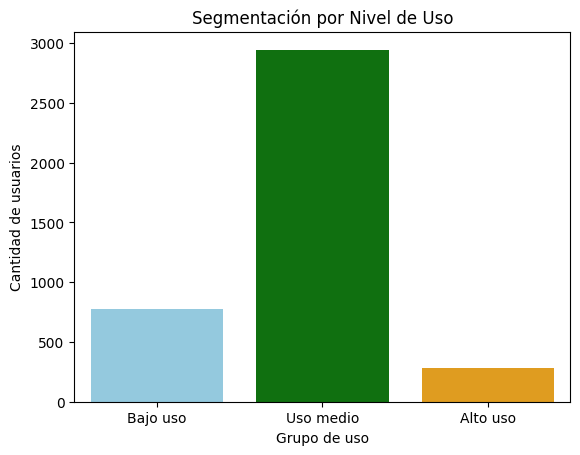

In [35]:
# Visualización segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette=['skyblue', 'green', 'orange'])
plt.title('Segmentación por Nivel de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

/tmp/ipykernel_1366/711103603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad',


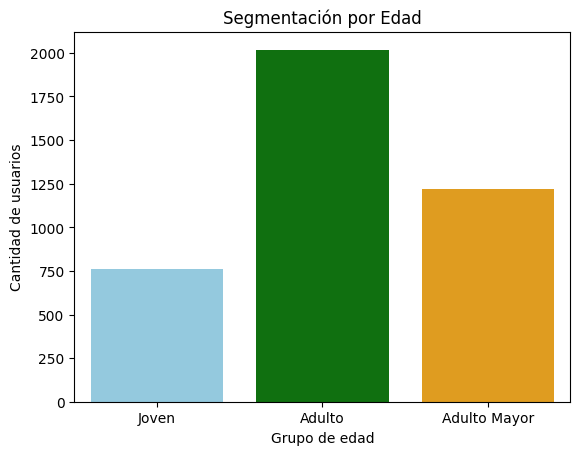

In [36]:
# Visualización segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['skyblue', 'green', 'orange'])
plt.title('Segmentación por Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

## Paso 7: Insight Ejecutivo para Stakeholders

### ⚠️ Problemas detectados en los datos

- age: tenía sentinel -999 (algunos registros) → reemplazado con mediana (48)
- city: tenía 469 nulos (11.7%) y 96 registros con "?" → reemplazados con pd.NA
- reg_date: 40 registros con fecha 2026 (imposible) → marcados como pd.NA
- duration y length: nulos estructurales por tipo de evento (MAR) → se mantienen

### 🔍 Segmentos por Edad

- Joven (< 30 años): ~750 usuarios → grupo más pequeño
- Adulto (30-59 años): ~2000 usuarios → grupo dominante
- Adulto Mayor (60+): ~1150 usuarios → grupo significativo

### 📊 Segmentos por Nivel de Uso

- Bajo uso: ~750 usuarios → poca actividad en llamadas y mensajes
- Uso medio: ~2900 usuarios → mayoría de la base de clientes
- Alto uso: ~300 usuarios → usuarios más activos y valiosos

➡️ Esto sugiere que ConnectaTel tiene una base mayoritariamente adulta
con uso moderado del servicio. Los usuarios de Alto uso son minoría
pero representan el mayor valor comercial.

### 💡 Recomendaciones

- Crear un plan intermedio entre Básico y Premium para usuarios de Uso medio
- Diseñar incentivos para migrar usuarios de Bajo uso a Uso medio
- Ofrecer beneficios especiales a usuarios de Alto uso para fidelizarlos
- Investigar usuarios con más de 100 minutos de llamada para detectar
  posibles fraudes o necesidades especiales
- Desarrollar campañas dirigidas al segmento Adulto Mayor que es significativo